In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.edgecolor':    '#444444',
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

C1, C2, C3   = '#4477AA', '#66CCEE', '#228833'
EMPH_COLOR   = '#CC3311'   # emphasized 
NEMP_COLOR   = '#4477AA'   # not emph. 
GRAY         = '#888888'

CAT_ORDER  = ['Shampoo & Conditioner', 'Moisturizer & Facial Care', 'Sunscreen & Sun Care']
CATS_LABEL = ['Shampoo &\nConditioner', 'Moisturizer &\nFacial Care', 'Sunscreen &\nSun Care']
CATS_SHORT = ['Shampoo', 'Moisturizer', 'Sunscreen']

REVIEW_FILE = 'All_Beauty.jsonl'
META_FILE   = 'meta_All_Beauty.jsonl'

KEYWORDS = {
    'Shampoo & Conditioner':     ['shampoo','conditioner','scalp','hair wash','keratin',
                                   'sulfate','scalp treatment','hair cleanser','dry shampoo'],
    'Moisturizer & Facial Care': ['moisturiz','serum','hyaluronic','retinol','facial care',
                                   'face cream','lotion','hydrat','mask','essence','toner'],
    'Sunscreen & Sun Care':      ['sunscreen','spf','uv','sun protection','sunblock',
                                   'sun care','uv protection','broad spectrum'],
}

def mock_banner(ax):
    ax.text(0.01, 0.99, 'MOCKED-UP — expected results based on ECT theory',
            transform=ax.transAxes, fontsize=8, color='#BB4444',
            va='top', ha='left', style='italic',
            bbox=dict(facecolor='#FFF5F5', edgecolor='#BB4444',
                      boxstyle='round,pad=0.3', linewidth=0.6))

print('✓')

✓


In [12]:
meta_df = pd.read_json(META_FILE, lines=True)

meta_df['feat_str'] = meta_df['features'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else ''
)
meta_df['desc_str'] = meta_df['description'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else ''
)

meta_df['full_text_lower'] = (
    meta_df['title'].fillna('') + ' ' +
    meta_df['feat_str'] + ' ' +
    meta_df['desc_str']
).str.lower()

def classify_product(text):
    for cat, kws in KEYWORDS.items():
        if any(kw in text for kw in kws):
            return cat
    return None

meta_df['subcategory'] = meta_df['full_text_lower'].apply(classify_product)

focal_meta = meta_df[meta_df['subcategory'].notna()].copy()

focal_meta['desc_words'] = (
    focal_meta['feat_str'] + ' ' + focal_meta['desc_str']
).str.split().str.len()

focal_meta['has_desc'] = focal_meta['desc_words'] > 0

print(f'focal_meta shape: {focal_meta.shape}')
print(focal_meta.groupby('subcategory')[['has_desc','desc_words']]
      .agg(n_products=('has_desc','count'),
           n_with_desc=('has_desc','sum'),
           coverage_pct=('has_desc', lambda x: x.mean()*100),
           median_words=('desc_words', lambda x: x[x>0].median()))
      .round(1))

focal_meta shape: (19619, 20)
                           n_products  n_with_desc  coverage_pct  median_words
subcategory                                                                   
Moisturizer & Facial Care       11072         4539          41.0         118.0
Shampoo & Conditioner            5461         2754          50.4         169.0
Sunscreen & Sun Care             3086          846          27.4         133.5


In [3]:
reviews_df = pd.read_json(REVIEW_FILE, lines=True)
reviews_df['parent_asin'] = reviews_df['parent_asin'].fillna(reviews_df['asin'])

reviews_df = reviews_df.merge(
    focal_meta[['parent_asin', 'subcategory']],
    on='parent_asin', how='inner'
)

reviews_df['text_len'] = reviews_df['text'].fillna('').str.split().str.len()

print(f'focal reviews shape: {reviews_df.shape}')
print(reviews_df.groupby('subcategory').agg(
    n_reviews=('rating', 'count'),
    pct_5star=('rating', lambda x: (x==5).mean()*100),
    median_len=('text_len', 'median')
).round(1))

focal reviews shape: (155605, 12)
                           n_reviews  pct_5star  median_len
subcategory                                                
Moisturizer & Facial Care      87314       63.1        22.0
Shampoo & Conditioner          49692       62.8        22.0
Sunscreen & Sun Care           18599       57.6        21.0


## Initial Results

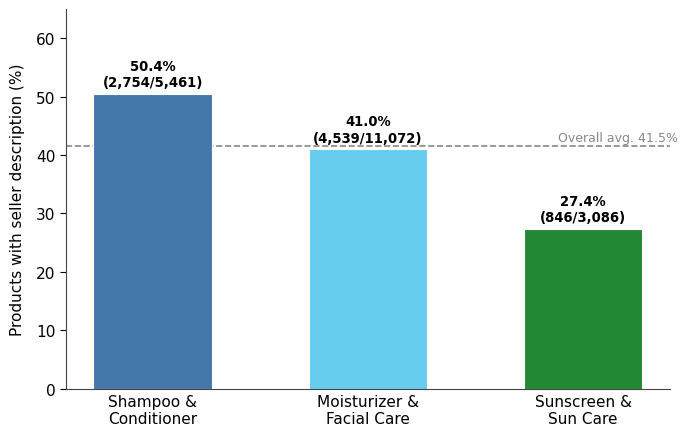

Figure 1 saved ✓


In [4]:
# Figure 1
cov = (
    focal_meta
    .groupby('subcategory')
    .agg(n_total=('has_desc','count'), n_with_desc=('has_desc','sum'))
    .assign(coverage=lambda d: d['n_with_desc'] / d['n_total'] * 100)
    .reindex(CAT_ORDER)
)

overall_pct = focal_meta['has_desc'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(CATS_LABEL, cov['coverage'],
              color=[C1, C2, C3], width=0.55,
              edgecolor='white', linewidth=0.8)

for bar, (_, row) in zip(bars, cov.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"{row['coverage']:.1f}%\n({int(row['n_with_desc']):,}/{int(row['n_total']):,})",
            ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.axhline(overall_pct, color=GRAY, linestyle='--', linewidth=1.2, zorder=0)
ax.text(2.44, overall_pct + 1.0,
        f'Overall avg. {overall_pct:.1f}%',
        color=GRAY, fontsize=9, ha='right')

ax.set_ylabel('Products with seller description (%)', labelpad=8)
ax.set_ylim(0, 65)
ax.set_yticks([0, 10, 20, 30, 40, 50, 60])
ax.tick_params(axis='x', length=0)


plt.tight_layout()
plt.savefig('fig1_description_coverage.png')
plt.show()
print('Figure 1 saved ✓')

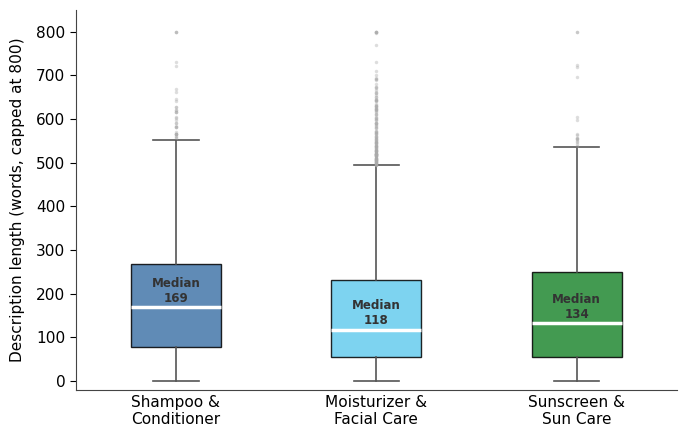

Figure 2 saved ✓


In [5]:
# ── Figure 2

has_desc = focal_meta[focal_meta['desc_words'] > 0].copy()

fig, ax = plt.subplots(figsize=(7, 4.5))

data_by_cat = [has_desc[has_desc['subcategory']==cat]['desc_words'].clip(upper=800).values
               for cat in CAT_ORDER]

bp = ax.boxplot(data_by_cat,
                positions=[0, 1, 2],
                widths=0.45,
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.2, color='#555'),
                capprops=dict(linewidth=1.2, color='#555'),
                flierprops=dict(marker='o', markersize=2.5,
                                markerfacecolor='#aaa', markeredgecolor='none',
                                alpha=0.4))

for patch, color in zip(bp['boxes'], [C1, C2, C3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

medians = [np.median(d) for d in data_by_cat]
for i, med in enumerate(medians):
    ax.text(i, med + 12, f'Median\n{med:.0f}',
            ha='center', fontsize=8.5, color='#333', fontweight='bold')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(CATS_LABEL)
ax.tick_params(axis='x', length=0)
ax.set_ylabel('Description length (words, capped at 800)', labelpad=8)
ax.set_ylim(-20, 850)


n_cats = [len(d) for d in data_by_cat]

plt.tight_layout()
plt.savefig('fig2_desc_length.png')
plt.show()
print('Figure 2 saved ✓')

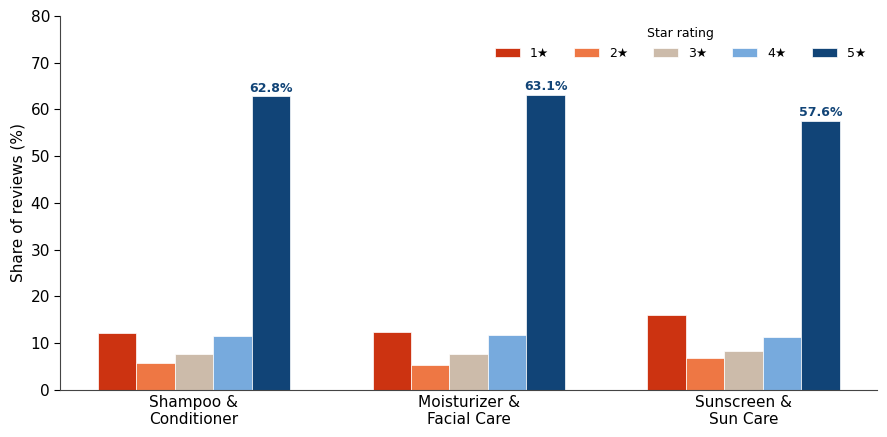

Figure 3 saved ✓


In [6]:
# ── Figure 3
rating_pct = (
    reviews_df
    .assign(rating_int=reviews_df['rating'].astype(int))
    .groupby(['subcategory', 'rating_int'])
    .size()
    .groupby(level='subcategory')
    .transform(lambda x: x / x.sum() * 100)
    .reset_index(name='pct')
)

pivot = (
    rating_pct
    .pivot(index='subcategory', columns='rating_int', values='pct')
    .fillna(0)
    .reindex(CAT_ORDER)
)

star_colors = ['#CC3311', '#EE7744', '#CCBBAA', '#77AADD', '#114477']
x = np.arange(3)
width = 0.14
offsets = np.linspace(-2, 2, 5) * width

fig, ax = plt.subplots(figsize=(9, 4.5))

for i, (star, col) in enumerate(zip([1, 2, 3, 4, 5], star_colors)):
    vals = [pivot.loc[cat, star] if star in pivot.columns else 0 for cat in CAT_ORDER]
    ax.bar(x + offsets[i], vals, width=width,
           color=col, edgecolor='white', linewidth=0.5, label=f'{star}★')

for j, cat in enumerate(CAT_ORDER):
    v5 = pivot.loc[cat, 5] if 5 in pivot.columns else 0
    ax.text(j + offsets[4], v5 + 1.0, f'{v5:.1f}%',
            ha='center', fontsize=9, color='#114477', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(CATS_LABEL)
ax.set_ylabel('Share of reviews (%)')
ax.set_ylim(0, 80)
ax.tick_params(axis='x', length=0)
ax.legend(title='Star rating', ncol=5, fontsize=9,
          loc='upper right', frameon=False, title_fontsize=9)


plt.tight_layout()
plt.savefig('fig3_rating_distribution.png')
plt.show()
print('Figure 3 saved ✓')

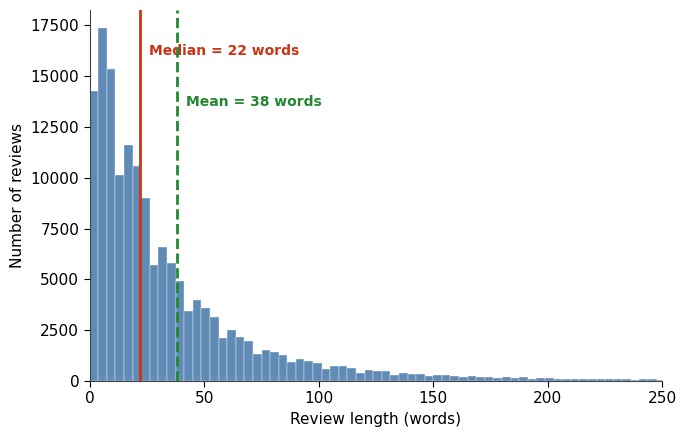

Figure 4 saved ✓


In [7]:
# ── Figure 4
med = reviews_df['text_len'].median()
mean = reviews_df['text_len'].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(reviews_df['text_len'].clip(upper=300),
        bins=80, color=C1, alpha=0.85,
        edgecolor='white', linewidth=0.3)

ax.axvline(med, color=EMPH_COLOR, linewidth=2, zorder=5)
ax.text(med + 4, ax.get_ylim()[1] * 0.88,
        f'Median = {med:.0f} words',
        color=EMPH_COLOR, fontsize=10, fontweight='bold')

ax.axvline(mean, color='#228833', linewidth=2, linestyle='--', zorder=5)
ax.text(mean + 4, ax.get_ylim()[1] * 0.74,
        f'Mean = {mean:.0f} words',
        color='#228833', fontsize=10, fontweight='bold')

ax.set_xlabel('Review length (words)')
ax.set_ylabel('Number of reviews')
ax.set_xlim(0, 250)

plt.tight_layout()
plt.savefig('fig4_review_length.png')
plt.show()
print('Figure 4 saved ✓')

## Expected Results (Mocked-up)

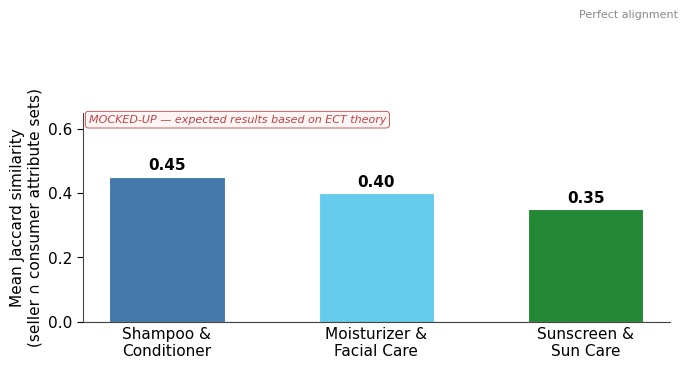

Figure 5 saved ✓


In [8]:
# ── Figure 5

mock4 = pd.DataFrame({
    'subcategory': CAT_ORDER,
    'mean_jaccard': [0.45, 0.40, 0.35],
}).set_index('subcategory').reindex(CAT_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(CATS_LABEL, mock4['mean_jaccard'],
            color=[C1, C2, C3], width=0.55,
              capsize=6, error_kw=dict(elinewidth=1.2, ecolor='#444'),
              edgecolor='white', linewidth=0.8)

for bar, (_, row) in zip(bars, mock4.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            row['mean_jaccard'] + 0.012,
            f"{row['mean_jaccard']:.2f}",
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(1.0, color=GRAY, linestyle=':', linewidth=1)
ax.text(2.44, 0.97, 'Perfect alignment', color=GRAY, fontsize=8, ha='right', va='top')
ax.axhline(0.0, color=GRAY, linestyle=':', linewidth=1)

ax.set_ylabel('Mean Jaccard similarity\n(seller ∩ consumer attribute sets)')
ax.set_ylim(0, 0.65)
ax.tick_params(axis='x', length=0)


mock_banner(ax)


plt.tight_layout()
plt.savefig('fig5_jaccard_alignment.png')
plt.show()
print('Figure 5 saved ✓')

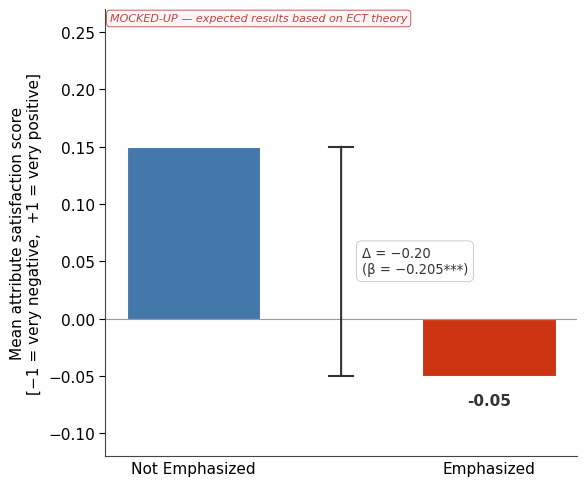

Figure 6 saved ✓


In [ ]:
# ── Figure 6

mock5 = pd.DataFrame({
    'group':  ['Not Emphasized', 'Emphasized'],
    'mean':   [0.15, -0.05],
    'color':  [NEMP_COLOR, EMPH_COLOR],
})

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(mock5['group'], mock5['mean'],
              color=mock5['color'],
              width=0.45,
              edgecolor='white', linewidth=0.8)

x_mid = 0.5
y_not_emph = 0.15
y_emph     = -0.05

ax.annotate('', xy=(x_mid, y_emph), xytext=(x_mid, y_not_emph),
            arrowprops=dict(arrowstyle='-', color='#333', lw=1.5,
                            shrinkA=0, shrinkB=0))
ax.plot([x_mid - 0.04, x_mid + 0.04], [y_not_emph, y_not_emph],
        color='#333', lw=1.5)
ax.plot([x_mid - 0.04, x_mid + 0.04], [y_emph, y_emph],
        color='#333', lw=1.5)
ax.text(x_mid + 0.07, (y_not_emph + y_emph) / 2,
        'Δ = −0.20\n(β = −0.205***)',
        fontsize=9.5, va='center', ha='left', color='#333',
        bbox=dict(facecolor='white', edgecolor='#ccc',
                  boxstyle='round,pad=0.4', linewidth=0.7))

for bar, (_, row) in zip(bars, mock5.iterrows()):
    offset = 0.018 if row['mean'] >= 0 else -0.025
    ax.text(bar.get_x() + bar.get_width() / 2,
            row['mean'] + offset,
            f"{row['mean']:+.2f}",
            ha='center', fontsize=11, fontweight='bold',
            color='white' if abs(row['mean']) > 0.05 else '#333')

ax.axhline(0, color='#999', linewidth=0.8)
ax.set_ylabel('Mean attribute satisfaction score\n[−1 = very negative,  +1 = very positive]')
ax.set_ylim(-0.12, 0.27)
ax.tick_params(axis='x', length=0)

mock_banner(ax)


plt.tight_layout()
plt.savefig('fig6_disconfirmation_main.png')
plt.show()
print('Figure 6 saved ✓')

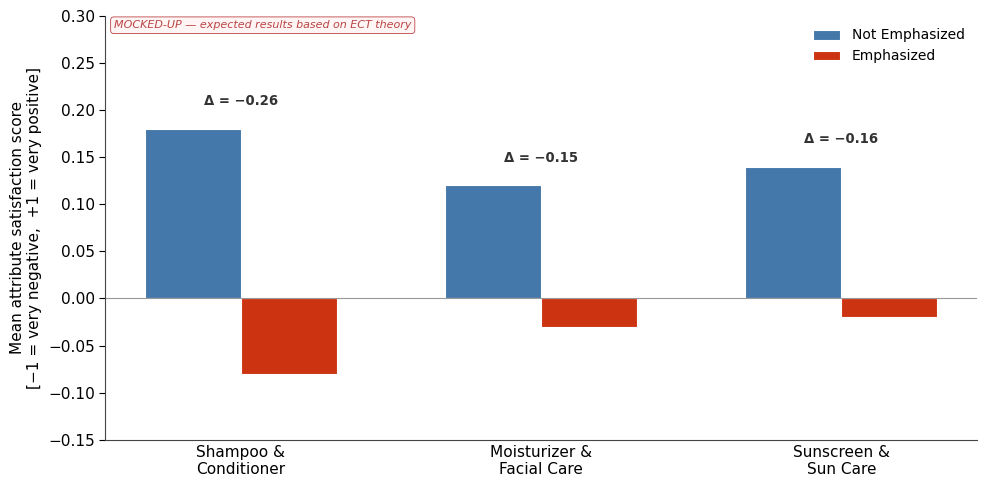

Figure 7 saved ✓


In [10]:
# ── Figure 7

mock6 = pd.DataFrame({
    'subcategory': CAT_ORDER,
    'not_emph':    [0.18,  0.12,  0.14],
    'emph':        [-0.08, -0.03, -0.02],
}).set_index('subcategory').reindex(CAT_ORDER)

mock6['delta'] = mock6['not_emph'] - mock6['emph']

x, width = np.arange(3), 0.32
fig, ax  = plt.subplots(figsize=(10, 5))

ax.bar(x - width/2, mock6['not_emph'], width=width,
       color=NEMP_COLOR, label='Not Emphasized',
       edgecolor='white', linewidth=0.8)
ax.bar(x + width/2, mock6['emph'], width=width,
       color=EMPH_COLOR, label='Emphasized',
       edgecolor='white', linewidth=0.8)

for xi, (_, row) in zip(x, mock6.iterrows()):
    ax.text(xi, max(row['not_emph'], 0) + 0.025,
            f"Δ = −{row['delta']:.2f}",
            ha='center', fontsize=9.5, color='#333', fontweight='bold')

ax.axhline(0, color='#999', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(CATS_LABEL)
ax.tick_params(axis='x', length=0)
ax.set_ylabel('Mean attribute satisfaction score\n[−1 = very negative,  +1 = very positive]')
ax.set_ylim(-0.15, 0.30)
ax.legend(frameon=False, fontsize=10, loc='upper right')

mock_banner(ax)

plt.tight_layout()
plt.savefig('fig7_disconfirmation_by_cat.png')
plt.show()
print('Figure 7 saved ✓')

In [ ]:
# ── Final sample statistics
final_df = reviews_df.merge(
    focal_meta[['parent_asin', 'has_desc']],
    on='parent_asin', how='inner'
)
final_df = final_df[final_df['has_desc'] == True]

summary = (
    final_df.groupby('subcategory')
    .agg(n_reviews=('rating', 'count'),
         n_products=('parent_asin', 'nunique'))
    .reindex(['Shampoo & Conditioner', 'Moisturizer & Facial Care', 'Sunscreen & Sun Care'])
)

print("=== Final Analytic Sample ===")
print(summary)
print(f"\nTotal  Reviews: {len(final_df):,}")
print(f"Total Products: {final_df['parent_asin'].nunique():,}")

=== Final Analytic Sample ===
                           n_reviews  n_products
subcategory                                     
Shampoo & Conditioner          28974        2754
Moisturizer & Facial Care      47543        4538
Sunscreen & Sun Care            7570         846

Total  Reviews: 84,087
Total Products: 8,138
